<a href="https://colab.research.google.com/github/Hasibur02/ASD-Detection-Deep-Learning/blob/main/RegNetY_800MF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================================
# ASD Detection Using Deep Learning & Transfer Learning
# 01. IMPORTS
# ==========================================================

In [ ]:
# ============================
# IMPORTS
# ============================

import os
import random
import warnings

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models import regnet_y_800mf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("IMPORTS COMPLETED")
print("=" * 60)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("NumPy       :", np.__version__)

IMPORTS COMPLETED
PyTorch     : 2.11.0+cu128
TorchVision : 0.26.0+cu128
NumPy       : 2.0.2


# ==========================================================
# Device Configuration (Colab + Tesla T4 Optimized)
# ==========================================================

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB"
    )

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB



# ==========================================================
#03. Dataset Setup
#==========================================================

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/AutismDataset"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

print("Dataset Path:", BASE_DIR)

Mounted at /content/drive
Dataset Path: /content/drive/MyDrive/AutismDataset


In [ ]:
def read_img(directory):

    image_paths = []
    labels = []

    for root, dirs, files in os.walk(directory):

        for image_file in sorted(files):

            if not image_file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                continue

            image_path = os.path.join(root, image_file)

            folder_name = os.path.basename(root).lower()
            file_name = image_file.lower()

            if folder_name == "autistic":
                label = "Autistic"

            elif folder_name in ["non_autistic", "non-autistic"]:
                label = "Non_Autistic"

            elif file_name.startswith("autistic"):
                label = "Autistic"

            elif file_name.startswith("non_autistic"):
                label = "Non_Autistic"

            else:
                continue

            image_paths.append(image_path)
            labels.append(label)

    return pd.DataFrame({
        "image_path": image_paths,
        "label": labels
    })

In [ ]:
import pandas as pd
train_df = read_img(train_dir)
valid_df = read_img(valid_dir)
test_df = read_img(test_dir)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 2542
Validation: 100
Testing: 300


# ==========================================================
# 04. DATASET STATISTICS
# ==========================================================

In [ ]:
datasets = {
    "Training": train_df,
    "Validation": valid_df,
    "Testing": test_df
}

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

# ----------------------------
# Dataset Size
# ----------------------------

for name, df in datasets.items():
    print(f"{name} Samples: {len(df):,}")

total_samples = sum(len(df) for df in datasets.values())

print(f"Total Samples: {total_samples:,}")


# ----------------------------
# Class Distribution
# ----------------------------

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name} Set:")
    print(df["label"].value_counts())

    print("\nPercentage:")
    print(
        (df["label"].value_counts(normalize=True) * 100)
        .round(2)
        .astype(str)
        + "%"
    )


# ----------------------------
# Missing Values
# ----------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name}:")
    print(df.isnull().sum())


print("\n" + "=" * 60)
print("Dataset statistics completed.")
print("=" * 60)

DATASET STATISTICS
Training Samples: 2,542
Validation Samples: 100
Testing Samples: 300
Total Samples: 2,942

CLASS DISTRIBUTION

Training Set:
label
Non_Autistic    1272
Autistic        1270
Name: count, dtype: int64

Percentage:
label
Non_Autistic    50.04%
Autistic        49.96%
Name: proportion, dtype: object

Validation Set:
label
Autistic        50
Non_Autistic    50
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

Testing Set:
label
Autistic        150
Non_Autistic    150
Name: count, dtype: int64

Percentage:
label
Autistic        50.0%
Non_Autistic    50.0%
Name: proportion, dtype: object

MISSING VALUES

Training:
image_path    0
label         0
dtype: int64

Validation:
image_path    0
label         0
dtype: int64

Testing:
image_path    0
label         0
dtype: int64

Dataset statistics completed.


# ==========================================================
# 05. IMAGE TRANSFORMATIONS
# ==========================================================

In [ ]:

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ==========================================================
# CNN Training Transform
# ==========================================================

train_transform_cnn = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.1)
    )
])


# ==========================================================
# ViT Training Transform
# ==========================================================

train_transform_vit = transforms.Compose([

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Validation / Test Transform
# ==========================================================

val_test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("Image transformations created successfully.")

Image transformations created successfully.


# ==========================================================
# 06. Hyperparameters
# ==========================================================

In [ ]:
# ==========================================================
# 06. HYPERPARAMETERS
# ==========================================================

# ----------------------------
# Training
# ----------------------------

NUM_EPOCHS = 25

LEARNING_RATE = 3e-5

WEIGHT_DECAY = 0.05

NUM_CLASSES = 2


# ----------------------------
# Batch Sizes
# ----------------------------

BATCH_SIZE = 32


# ----------------------------
# DataLoader
# ----------------------------

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ----------------------------
# Early Stopping
# ----------------------------

PATIENCE = 7


# ----------------------------
# Reproducibility
# ----------------------------

RANDOM_SEED = 42


# ----------------------------
# Display
# ----------------------------

print("=" * 60)
print("HYPERPARAMETERS")
print("=" * 60)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Workers         : {NUM_WORKERS}")
print(f"Pin Memory      : {PIN_MEMORY}")
print(f"Early Stopping  : {PATIENCE}")
print(f"Random Seed     : {RANDOM_SEED}")

print("=" * 60)

HYPERPARAMETERS
Epochs          : 25
Learning Rate   : 3e-05
Weight Decay    : 0.05
Number of Classes: 2
Batch Size      : 32
Workers         : 2
Pin Memory      : True
Early Stopping  : 7
Random Seed     : 42


# ==========================================================
# 7. Dataset Class & DataLoaders
# ==========================================================

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image


# ==========================================================
# Hyperparameters
# ==========================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================
# CNN Validation / Test Transform
# ==========================================================

val_test_transform_cnn = transforms.Compose([

    transforms.Resize(
        (224, 224),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==========================================================
# Autism Dataset Class
# ==========================================================

class AutismDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        label_encoder=None,
        fit_label_encoder=False
    ):

        self.data = dataframe.reset_index(drop=True)

        self.transform = transform

        self.image_paths = self.data["image_path"].values


        # --------------------------------------------------
        # Label Encoding
        # --------------------------------------------------

        if label_encoder is None:

            self.label_encoder = LabelEncoder()

            if fit_label_encoder:

                self.labels = self.label_encoder.fit_transform(
                    self.data["label"]
                )

            else:

                raise ValueError(
                    "Set fit_label_encoder=True for training dataset"
                )

        else:

            self.label_encoder = label_encoder

            self.labels = self.label_encoder.transform(
                self.data["label"]
            )


    # ------------------------------------------------------
    # Number of Samples
    # ------------------------------------------------------

    def __len__(self):

        return len(self.data)


    # ------------------------------------------------------
    # Load One Image
    # ------------------------------------------------------

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception:

            print("Error loading:", image_path)

            image = Image.new(
                "RGB",
                (224, 224),
                "black"
            )


        # Apply transformation

        if self.transform:

            image = self.transform(image)


        # Label

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        return image, label


    # ------------------------------------------------------
    # Label Encoder
    # ------------------------------------------------------

    def get_label_encoder(self):

        return self.label_encoder


    # ------------------------------------------------------
    # Class Names
    # ------------------------------------------------------

    def get_class_names(self):

        return self.label_encoder.classes_


# ==========================================================
# DataLoader Creation Function
# ==========================================================

def create_dataloaders(
    train_df,
    val_df,
    test_df,
    train_transform,
    val_test_transform,
    batch_size=32,
    num_workers=2
):


    # ======================================================
    # Training Dataset
    # ======================================================

    train_dataset = AutismDataset(

        train_df,

        transform=train_transform,

        fit_label_encoder=True
    )


    # Get Label Encoder

    label_encoder = train_dataset.get_label_encoder()


    # ======================================================
    # Validation Dataset
    # ======================================================

    val_dataset = AutismDataset(

        val_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # Test Dataset
    # ======================================================

    test_dataset = AutismDataset(

        test_df,

        transform=val_test_transform,

        label_encoder=label_encoder
    )


    # ======================================================
    # DataLoader Arguments
    # ======================================================

    loader_args = {

        "batch_size": batch_size,

        "num_workers": num_workers,

        "pin_memory": PIN_MEMORY
    }


    if num_workers > 0:

        loader_args["persistent_workers"] = True

        loader_args["prefetch_factor"] = 2


    # ======================================================
    # Training DataLoader
    # ======================================================

    train_loader = DataLoader(

        train_dataset,

        shuffle=True,

        drop_last=True,

        **loader_args
    )


    # ======================================================
    # Validation DataLoader
    # ======================================================

    val_loader = DataLoader(

        val_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Test DataLoader
    # ======================================================

    test_loader = DataLoader(

        test_dataset,

        shuffle=False,

        **loader_args
    )


    # ======================================================
    # Summary
    # ======================================================

    print("=" * 60)
    print("DATALOADER SUMMARY")
    print("=" * 60)

    print(
        f"Training Images   : {len(train_dataset):,}"
    )

    print(
        f"Validation Images : {len(val_dataset):,}"
    )

    print(
        f"Testing Images    : {len(test_dataset):,}"
    )

    print()

    print(
        f"Batch Size        : {batch_size}"
    )

    print(
        f"Workers           : {num_workers}"
    )

    print(
        f"Pin Memory        : {PIN_MEMORY}"
    )

    print()

    print("Classes:")
    print(label_encoder.classes_)

    print("=" * 60)


    return (
        train_loader,
        val_loader,
        test_loader,
        label_encoder
    )


# ==========================================================
# 7A. Create RegNet CNN DataLoaders
# ==========================================================

train_loader_cnn, val_loader_cnn, test_loader_cnn, label_encoder = create_dataloaders(

    train_df,
    valid_df,
    test_df,

    train_transform_cnn,
    val_test_transform_cnn,

    batch_size=32,
    num_workers=2
)


print("=" * 60)
print("RegNetY-800MF DataLoaders Created")
print("=" * 60)

print(
    f"Training samples   : "
    f"{len(train_loader_cnn.dataset):,}"
)

print(
    f"Validation samples : "
    f"{len(val_loader_cnn.dataset):,}"
)

print(
    f"Test samples       : "
    f"{len(test_loader_cnn.dataset):,}"
)

print()

print(
    f"Training batches   : "
    f"{len(train_loader_cnn):,}"
)

print(
    f"Validation batches : "
    f"{len(val_loader_cnn):,}"
)

print(
    f"Test batches       : "
    f"{len(test_loader_cnn):,}"
)

print()

print(
    f"Classes            : "
    f"{list(label_encoder.classes_)}"
)

print(
    f"Number of classes  : "
    f"{len(label_encoder.classes_)}"
)


# ==========================================================
# 7B. Verify CNN Batch
# ==========================================================

images, labels = next(
    iter(train_loader_cnn)
)

print()
print("RegNetY-800MF Batch Verification")
print("=" * 60)

print(
    f"Image batch shape : "
    f"{images.shape}"
)

print(
    f"Label shape       : "
    f"{labels.shape}"
)

print("=" * 60)


DATALOADER SUMMARY
Training Images   : 2,542
Validation Images : 100
Testing Images    : 300

Batch Size        : 32
Workers           : 2
Pin Memory        : True

Classes:
['Autistic' 'Non_Autistic']
RegNetY-800MF DataLoaders Created
Training samples   : 2,542
Validation samples : 100
Test samples       : 300

Training batches   : 79
Validation batches : 4
Test batches       : 10

Classes            : ['Autistic', 'Non_Autistic']
Number of classes  : 2

RegNetY-800MF Batch Verification
Image batch shape : torch.Size([32, 3, 224, 224])
Label shape       : torch.Size([32])


# ==========================================================
# 8. RegNetY-800MF Model Definition
# ==========================================================

In [ ]:
# ============================================================
# 08. REGNETY-800MF MODEL DEFINITION
# ============================================================

from torchvision.models import regnet_y_800mf
import torch.nn as nn


def create_regnet_model(num_classes=2):

    model = regnet_y_800mf(weights=None)

    # Custom classifier used during training
    # The checkpoint expects 784 input features, not 400.
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(784, num_classes)
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

print("=" * 60)
print("CREATING REGNETY-800MF MODEL")
print("=" * 60)

regnet_model = create_regnet_model(
    num_classes=NUM_CLASSES
).to(device)


# ============================================================
# MODEL SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in regnet_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in regnet_model.parameters()
    if p.requires_grad
)

print(f"Model                : RegNetY-800MF")
print(f"Device               : {device}")
print(f"Total Parameters     : {total_params / 1e6:.2f} M")
print(f"Trainable Parameters : {trainable_params / 1e6:.2f} M")
print(f"Number of Classes    : {NUM_CLASSES}")

print("=" * 60)
print("✓ RegNetY-800MF architecture is ready")

CREATING REGNETY-800MF MODEL
Model                : RegNetY-800MF
Device               : cuda
Total Parameters     : 5.65 M
Trainable Parameters : 5.65 M
Number of Classes    : 2
✓ RegNetY-800MF architecture is ready


# ==========================================================
# 9. ModelTrainer Class Definition
# ==========================================================

In [ ]:
# ============================================================
# SECTION 8 — MODEL TRAINER
# ============================================================

import copy
import time

import torch
import torch.nn as nn

from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler


class ModelTrainer:

    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        device
    ):

        self.model = model.to(device)

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.device = device

        # Training history
        self.train_losses = []
        self.val_losses = []

        self.train_accuracies = []
        self.val_accuracies = []


    # ========================================================
    # TRAIN MODEL
    # ========================================================

    def train_model(
        self,
        num_epochs=25,
        lr=3e-5,
        weight_decay=0.05,
        patience=7,
        model_name="RegNetY-800MF"
    ):

        # ----------------------------------------------------
        # Loss Function
        # ----------------------------------------------------

        criterion = nn.CrossEntropyLoss(
            label_smoothing=0.1
        )


        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = AdamW(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )


        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )


        # ----------------------------------------------------
        # Mixed Precision
        # ----------------------------------------------------

        scaler = GradScaler(
            "cuda",
            enabled=(self.device.type == "cuda")
        )


        # ----------------------------------------------------
        # Best Model Tracking
        # ----------------------------------------------------

        best_val_acc = 0.0

        best_weights = copy.deepcopy(
            self.model.state_dict()
        )

        patience_counter = 0


        # ----------------------------------------------------
        # Training Start
        # ----------------------------------------------------

        start_time = time.time()

        print("=" * 60)
        print(f"TRAINING: {model_name}")
        print("=" * 60)

        print(f"Epochs       : {num_epochs}")
        print(f"Learning Rate: {lr}")
        print(f"Weight Decay : {weight_decay}")
        print(f"Patience     : {patience}")
        print(f"Device       : {self.device}")

        print("=" * 60)


        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(num_epochs):

            print(
                f"\nEpoch {epoch + 1}/{num_epochs}"
            )

            print("-" * 60)


            # =================================================
            # TRAINING PHASE
            # =================================================

            self.model.train()

            running_loss = 0.0
            correct = 0
            total = 0


            train_bar = tqdm(
                self.train_loader,
                desc="Train"
            )


            for images, labels in train_bar:

                images = images.to(
                    self.device,
                    non_blocking=True
                )

                labels = labels.to(
                    self.device,
                    non_blocking=True
                )


                # Clear gradients
                optimizer.zero_grad(
                    set_to_none=True
                )


                # Forward pass
                with autocast(
                    device_type=self.device.type,
                    enabled=(self.device.type == "cuda")
                ):

                    outputs = self.model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )


                # Predictions
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )


                # ------------------------------------------------
                # Backpropagation
                # ------------------------------------------------

                scaler.scale(loss).backward()


                # Gradient clipping
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    max_norm=1.0
                )


                # Optimizer step
                scaler.step(optimizer)

                scaler.update()


                # ------------------------------------------------
                # Statistics
                # ------------------------------------------------

                batch_size = images.size(0)

                running_loss += (
                    loss.item() * batch_size
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += batch_size


                train_bar.set_postfix(
                    Loss=f"{running_loss / total:.4f}",
                    Acc=f"{correct / total:.4f}"
                )


            # Epoch training metrics

            train_loss = running_loss / total
            train_acc = correct / total


            self.train_losses.append(
                train_loss
            )

            self.train_accuracies.append(
                train_acc
            )


            print(
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f}"
            )


            # =================================================
            # VALIDATION PHASE
            # =================================================

            self.model.eval()

            running_loss = 0.0
            correct = 0
            total = 0


            with torch.no_grad():

                val_bar = tqdm(
                    self.val_loader,
                    desc="Val"
                )


                for images, labels in val_bar:

                    images = images.to(
                        self.device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        self.device,
                        non_blocking=True
                    )


                    with autocast(
                        device_type=self.device.type,
                        enabled=(self.device.type == "cuda")
                    ):

                        outputs = self.model(images)

                        loss = criterion(
                            outputs,
                            labels
                        )


                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )


                    batch_size = images.size(0)

                    running_loss += (
                        loss.item() * batch_size
                    )

                    correct += (
                        predictions == labels
                    ).sum().item()

                    total += batch_size


                    val_bar.set_postfix(
                        Loss=f"{running_loss / total:.4f}",
                        Acc=f"{correct / total:.4f}"
                    )


            # Epoch validation metrics

            val_loss = running_loss / total
            val_acc = correct / total


            self.val_losses.append(
                val_loss
            )

            self.val_accuracies.append(
                val_acc
            )


            print(
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )


            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                best_weights = copy.deepcopy(
                    self.model.state_dict()
                )

                patience_counter = 0


                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict":
                            self.model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "best_val_acc":
                            best_val_acc
                    },
                    f"best_{model_name}.pth"
                )


                print(
                    f"✓ Best model saved "
                    f"(Val Acc: {best_val_acc:.4f})"
                )


            else:

                patience_counter += 1


            # =================================================
            # LEARNING RATE
            # =================================================

            scheduler.step()

            current_lr = scheduler.get_last_lr()[0]

            print(
                f"Learning Rate: {current_lr:.2e}"
            )


            # =================================================
            # EARLY STOPPING
            # =================================================

            if patience_counter >= patience:

                print(
                    "\n✓ Early stopping triggered."
                )

                break


        # ====================================================
        # RESTORE BEST MODEL
        # ====================================================

        self.model.load_state_dict(
            best_weights
        )


        elapsed = time.time() - start_time


        print("\n" + "=" * 60)
        print("TRAINING COMPLETED")
        print("=" * 60)

        print(
            f"Training Time          : "
            f"{elapsed // 60:.0f}m "
            f"{elapsed % 60:.0f}s"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print("=" * 60)


        return self.model

In [ ]:
# ============================================================
# CREATE REGNET TRAINER
# ============================================================

print("Creating RegNet Trainer...")

regnet_trainer = ModelTrainer(
    model=regnet_model,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    device=device
)

print("✓ RegNetY-800MF trainer is ready.")

Creating RegNet Trainer...
✓ RegNetY-800MF trainer is ready.


# ==========================================================
# 10. Train RegNetY-800MF Model
# ==========================================================

In [ ]:
# ==========================================================
# TRAIN REGNETY-800MF
# ==========================================================

print("=" * 60)
print(""Training RegNet..."")
print("=" * 60)

regnet_model = regnet_trainer.train_model(
    num_epochs=25,
    lr=3e-5,
    weight_decay=0.05,
    patience=7,
    save_best=True,
    model_name="RegNetY-800MF"
)

Training RegNet...
Starting training for 25 epochs...
------------------------------------------------------------

Epoch 1/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:53<00:00,  1.46it/s, Acc=0.6226, Loss=0.6606]


Train Loss: 0.6606 Acc: 0.6226


Val: 100%|██████████| 4/4 [00:01<00:00,  3.88it/s, Acc=0.7100, Loss=0.5795]


Val Loss: 0.5795 Acc: 0.7100
✓ Best model saved (Val Acc: 0.7100)
Learning Rate: 9.96e-05

Epoch 2/25
------------------------------------------------------------


...

Val Loss: 0.4348 Acc: 0.8100
Learning Rate: 1.81e-05

Epoch 19/25
------------------------------------------------------------


Train: 100%|██████████| 79/79 [00:29<00:00,  2.68it/s, Acc=0.9569, Loss=0.2800]


Train Loss: 0.2800 Acc: 0.9569


Val: 100%|██████████| 4/4 [00:00<00:00,  5.26it/s, Acc=0.8400, Loss=0.4123]

Val Loss: 0.4123 Acc: 0.8400
Learning Rate: 1.36e-05
Early stopping triggered

Training completed in 9m 57s
Best Validation Accuracy: 0.8400


# ==========================================================
# 10. Evaluation RegNetY-800MF Model
# ==========================================================

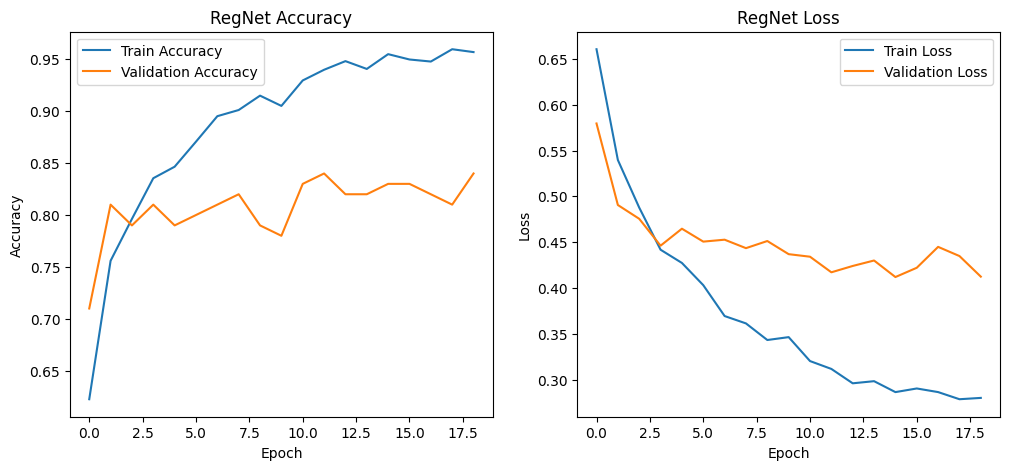

In [ ]:
history_available = (
    hasattr(regnet_trainer, "train_accuracies") and
    hasattr(regnet_trainer, "val_accuracies") and
    hasattr(regnet_trainer, "train_losses") and
    hasattr(regnet_trainer, "val_losses")
)

if history_available:
    plt.figure(figsize=(12,5))

    # Accuracy Plot (assuming it also tracked accuracies, common with losses)
    plt.subplot(1,2,1)
    plt.plot(regnet_trainer.train_accuracies, label="Train Accuracy")
    plt.plot(regnet_trainer.val_accuracies, label="Validation Accuracy")
    plt.title("RegNet Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(regnet_trainer.train_losses, label="Train Loss")
    plt.plot(regnet_trainer.val_losses, label="Validation Loss")
    plt.title("RegNet Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()
else:
    print("⚠ Training history not found in trainer object for RegNet.")

❌ No RegNet .pth/.pt model checkpoint found. Using currently trained model for evaluation.

RegNet Test Performance
Test Accuracy : 0.9300
Test Samples  : 300

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Autistic       0.92      0.94      0.93       150
Non_Autistic       0.94      0.92      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300


Confusion Matrix
------------------------------------------------------------
[[141   9]
 [ 12 138]]


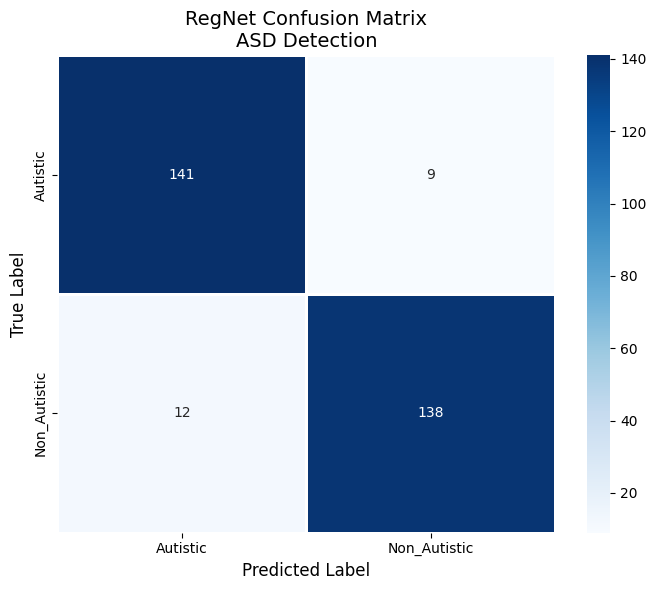

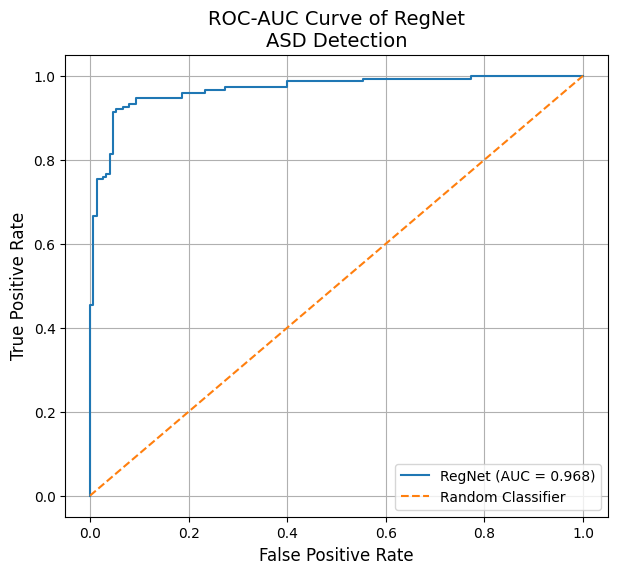

RegNet ROC-AUC Score: 0.9679


In [ ]:
# ==========================================================
# RegNet Evaluation
# ==========================================================

import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# ----------------------------------------------------------
# 1. Find Saved Model Checkpoint Automatically (for RegNet)
# ----------------------------------------------------------

# Assuming a checkpoint named 'best_RegNet_ASD.pth' would be saved
# Similar to ViT, AlexNet, etc.
checkpoint_path = None

# Search for the RegNet specific checkpoint
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "best_RegNet_ASD.pth": # Specific name based on train_model call
            checkpoint_path = os.path.join(root, file)
            break
    if checkpoint_path:
        break

# If specific not found, fall back to general (less ideal if multiple models)
if checkpoint_path is None:
    for root, dirs, files in os.walk("/content"):
        for file in files:
            if (file.endswith(".pth") or file.endswith(".pt")) and "RegNet" in file: # Look for RegNet in name
                checkpoint_path = os.path.join(root, file)
                break
        if checkpoint_path:
            break


if checkpoint_path is None:
    print("❌ No RegNet .pth/.pt model checkpoint found. Using currently trained model for evaluation.")
    # If no checkpoint, use the model as it is after training
    regnet_model.eval()
else:
    print("="*60)
    print("RegNet Checkpoint Found:")
    print(checkpoint_path)
    print("="*60)

    # 2. Load Best RegNet Model
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    # Handle both saved model formats
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        regnet_trainer.model.load_state_dict(
            checkpoint["model_state_dict"]
        )
    else:
        regnet_trainer.model.load_state_dict(
            checkpoint
        )
    regnet_trainer.model.eval()
    print("✅ Best RegNet model loaded")


# ----------------------------------------------------------
# 3. Test Evaluation and Prediction Collection
# ----------------------------------------------------------

regnet_preds = []
regnet_labels = []
regnet_probs = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in regnet_trainer.test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = regnet_trainer.model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        regnet_preds.extend(preds.cpu().numpy())
        regnet_labels.extend(labels.cpu().numpy())
        regnet_probs.extend(probabilities[:, 1].cpu().numpy()) # Probability of 'Non_Autistic' (positive class)

regnet_test_acc = correct / total

print("\n" + "="*60)
print("RegNet Test Performance")
print("="*60)

print(f"Test Accuracy : {regnet_test_acc:.4f}")
print(f"Test Samples  : {total}")
print("="*60)


# ----------------------------------------------------------
# 4. Classification Report
# ----------------------------------------------------------

print("\nClassification Report")
print("-"*60)

print(
    classification_report(
        regnet_labels,
        regnet_preds,
        target_names=regnet_trainer.test_loader.dataset.get_class_names() # Get class names from dataset
    )
)


# ----------------------------------------------------------
# 5. Confusion Matrix
# ----------------------------------------------------------

print("\nConfusion Matrix")
print("-"*60)

cm_regnet = confusion_matrix(
    regnet_labels,
    regnet_preds
)

print(cm_regnet)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_regnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=regnet_trainer.test_loader.dataset.get_class_names(),
    yticklabels=regnet_trainer.test_loader.dataset.get_class_names(),
    linewidths=1,
    cbar=True
)

plt.title("RegNet Confusion Matrix\nASD Detection", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 6. ROC-AUC Curve
# ----------------------------------------------------------

from sklearn.metrics import roc_curve, auc

fpr_regnet, tpr_regnet, thresholds_regnet = roc_curve(
    regnet_labels,
    regnet_probs
)

roc_auc_regnet = auc(
    fpr_regnet,
    tpr_regnet
)

plt.figure(figsize=(7,6))
plt.plot(
    fpr_regnet,
    tpr_regnet,
    label=f"RegNet (AUC = {roc_auc_regnet:.3f})"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)
plt.title("ROC-AUC Curve of RegNet\nASD Detection", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"RegNet ROC-AUC Score: {roc_auc_regnet:.4f}")

In [ ]:
regnet_model = create_regnet_model(num_classes=NUM_CLASSES)

regnet_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth",
        map_location=device
    )
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [ ]:
import torch

# Create model
regnet_model = create_regnet_model()

# Load weights
model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

regnet_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet_Y800MF loaded successfully!")

✅ RegNet_Y800MF loaded successfully!


In [ ]:
# ============================================================
# REGNETY-800MF — ACCURACY
# ============================================================

accuracy = correct / total

print("=" * 60)
print("REGNETY-800MF — TEST ACCURACY")
print("=" * 60)

print(f"Accuracy : {accuracy * 100:.2f}%")

print("=" * 60)

REGNETY-800MF — TEST ACCURACY
Accuracy : 93.00%


In [ ]:
# ============================================================
# REGNETY-800MF — PRECISION, RECALL, F1-SCORE
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)

print("=" * 60)
print("REGNETY-800MF — TEST METRICS")
print("=" * 60)

print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("=" * 60)

REGNETY-800MF — TEST METRICS
Precision : 93.88%
Recall    : 92.00%
F1-Score  : 92.93%


REGNETY-800MF — CONFUSION MATRIX
[[141   9]
 [ 12 138]]


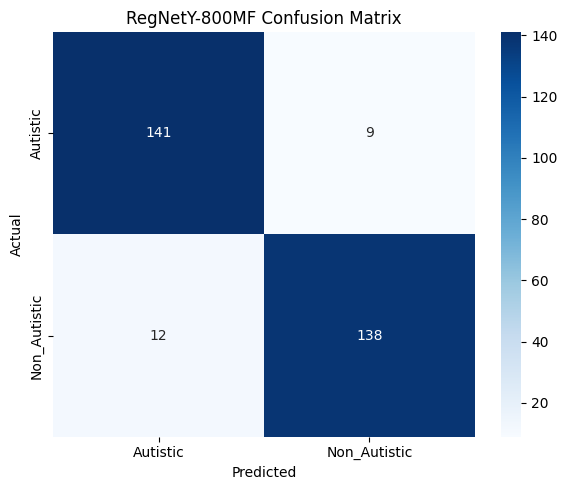

In [ ]:
# ============================================================
# REGNETY-800MF — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

class_names = (
    test_loader_cnn.dataset.get_class_names()
)

print("=" * 60)
print("REGNETY-800MF — CONFUSION MATRIX")
print("=" * 60)

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("RegNetY-800MF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

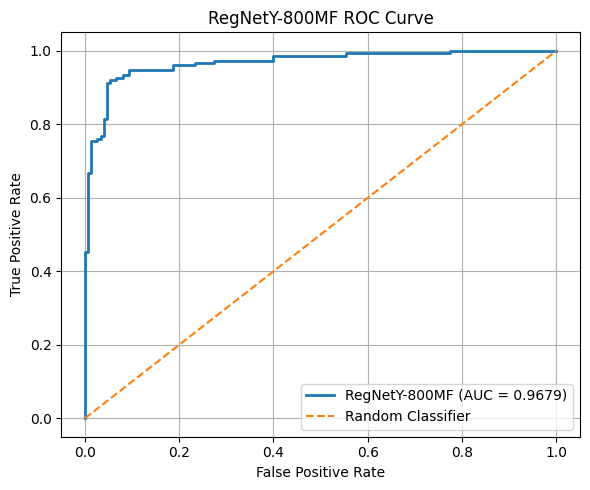

ROC-AUC Score : 0.9679


In [ ]:
# ============================================================
# REGNETY-800MF — ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"RegNetY-800MF (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("RegNetY-800MF ROC Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("=" * 60)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print("=" * 60)

In [ ]:
# ============================================================
# REGNETY-800MF — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 60)
print("REGNETY-800MF — CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=(
            test_loader_cnn.dataset.get_class_names()
        ),
        digits=4,
        zero_division=0
    )
)

REGNETY-800MF — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Autistic     0.9216    0.9400    0.9307       150
Non_Autistic     0.9388    0.9200    0.9293       150

    accuracy                         0.9300       300
   macro avg     0.9302    0.9300    0.9300       300
weighted avg     0.9302    0.9300    0.9300       300



In [ ]:
# ==========================================================
# Final Model Performance Summary (IEEE Style)
# ==========================================================

import pandas as pd

results_summary = pd.DataFrame({

    "Model": [
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture": [
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Accuracy (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)": [
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1-score (%)": [
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC-AUC": [
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ]

})

results_summary = results_summary.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_summary.index += 1

print("="*90)
print("ASD Detection Model Performance Comparison")
print("="*90)

print(results_summary)

print("\nBest Performing Model")
print("-"*90)

best = results_summary.iloc[0]

print(f"Model      : {best['Model']}")
print(f"Accuracy   : {best['Accuracy (%)']:.2f}%")
print(f"Precision  : {best['Precision (%)']:.2f}%")
print(f"Recall     : {best['Recall (%)']:.2f}%")
print(f"F1-score   : {best['F1-score (%)']:.2f}%")
print(f"ROC-AUC    : {best['ROC-AUC']:.4f}")

print("\nArchitecture-wise Average Accuracy")
print("-"*90)

print(
    results_summary.groupby("Architecture")["Accuracy (%)"].agg(
        ["mean","max","min"]
    )
)

ASD Detection Model Performance Comparison
                           Model Architecture  Accuracy (%)  Precision (%)  \
1                 RegNet X-400MF          CNN         93.00          93.00   
2                    MobileNetV2          CNN         88.33          88.83   
3                    DenseNet121          CNN         88.33          88.83   
4              MobileNetV3-Large          CNN         88.00          88.33   
5  Vision Transformer (ViT-B/16)  Transformer         87.33          87.67   
6                        AlexNet          CNN         84.67          85.43   

   Recall (%)  F1-score (%)  ROC-AUC  
1       93.00         93.00   0.9679  
2       88.33         88.30   0.9535  
3       88.33         88.30   0.9533  
4       88.00         87.97   0.9510  
5       87.33         87.27   0.9300  
6       84.67         84.58   0.9336  

Best Performing Model
------------------------------------------------------------------------------------------
Model      : RegNet X-4

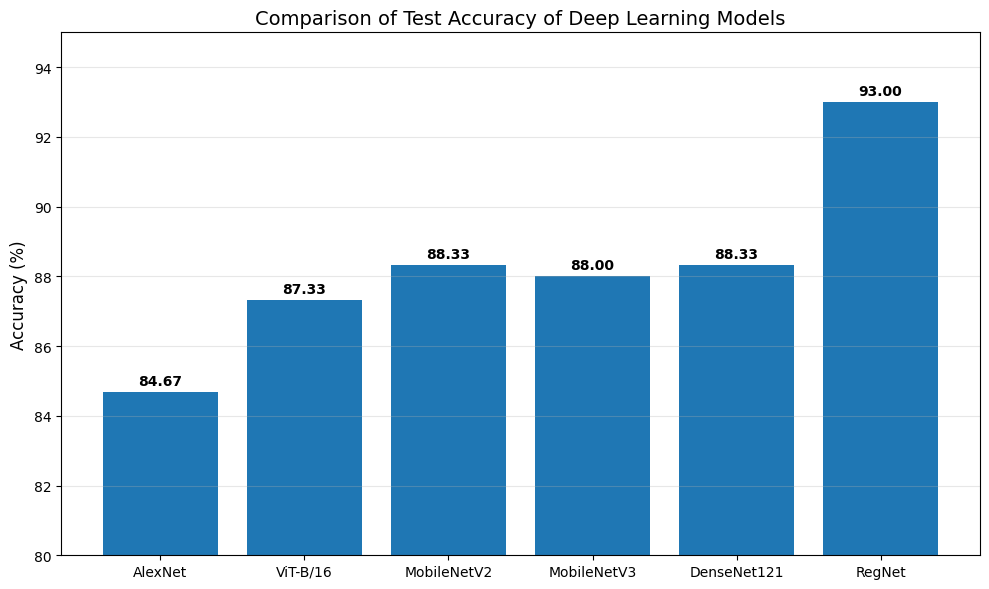

In [ ]:
plt.figure(figsize=(10,6))

models = [
    "AlexNet",
    "ViT-B/16",
    "MobileNetV2",
    "MobileNetV3",
    "DenseNet121",
    "RegNet"
]

accuracy = [
    84.67,
    87.33,
    88.33,
    88.00,
    88.33,
    93.00
]

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Test Accuracy of Deep Learning Models", fontsize=14)

plt.ylim(80,95)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.2,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

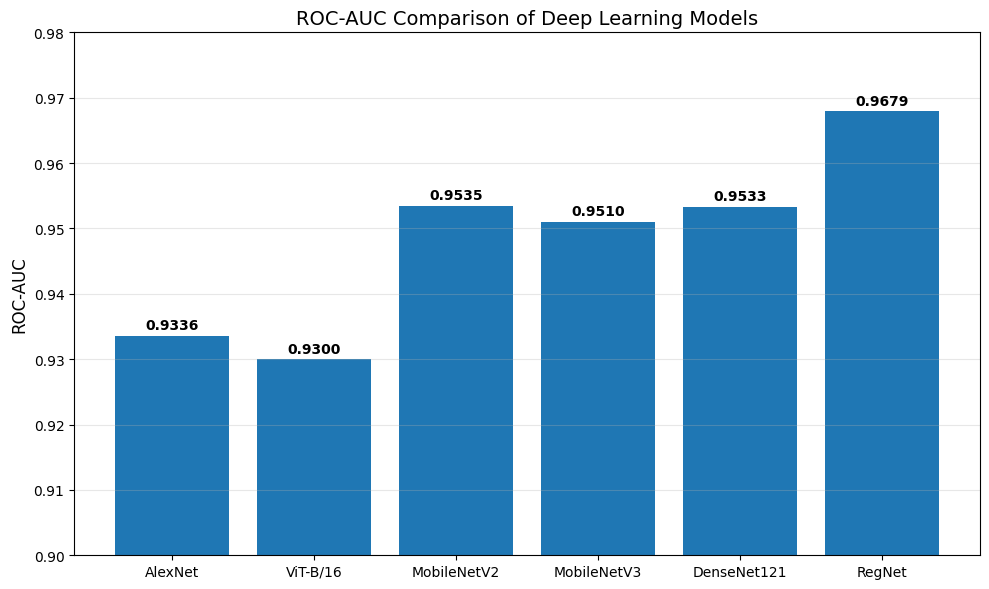

In [ ]:
plt.figure(figsize=(10,6))

roc_auc = [
    0.9336,
    0.9300,
    0.9535,
    0.9510,
    0.9533,
    0.9679
]

bars = plt.bar(models, roc_auc)

plt.ylabel("ROC-AUC", fontsize=12)
plt.title("ROC-AUC Comparison of Deep Learning Models", fontsize=14)

plt.ylim(0.90,0.98)

for bar, value in zip(bars, roc_auc):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

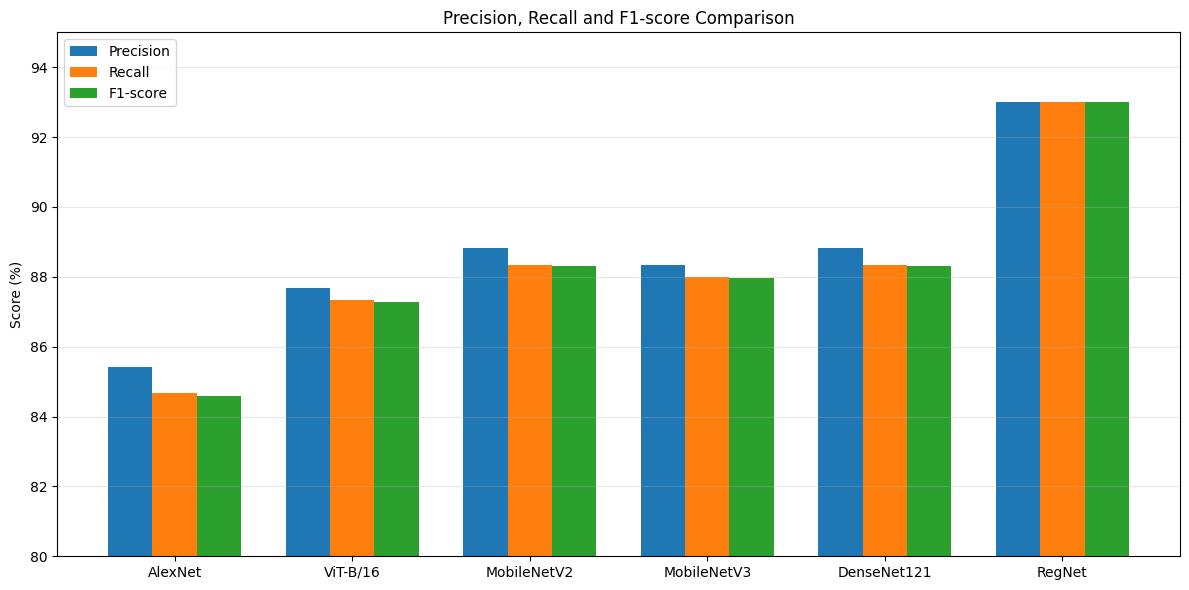

In [ ]:
import numpy as np

precision = [85.43,87.67,88.83,88.33,88.83,93.00]
recall = [84.67,87.33,88.33,88.00,88.33,93.00]
f1 = [84.58,87.27,88.30,87.97,88.30,93.00]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x-width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x+width, f1, width, label="F1-score")

plt.xticks(x, models)

plt.ylabel("Score (%)")
plt.title("Precision, Recall and F1-score Comparison")

plt.ylim(80,95)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

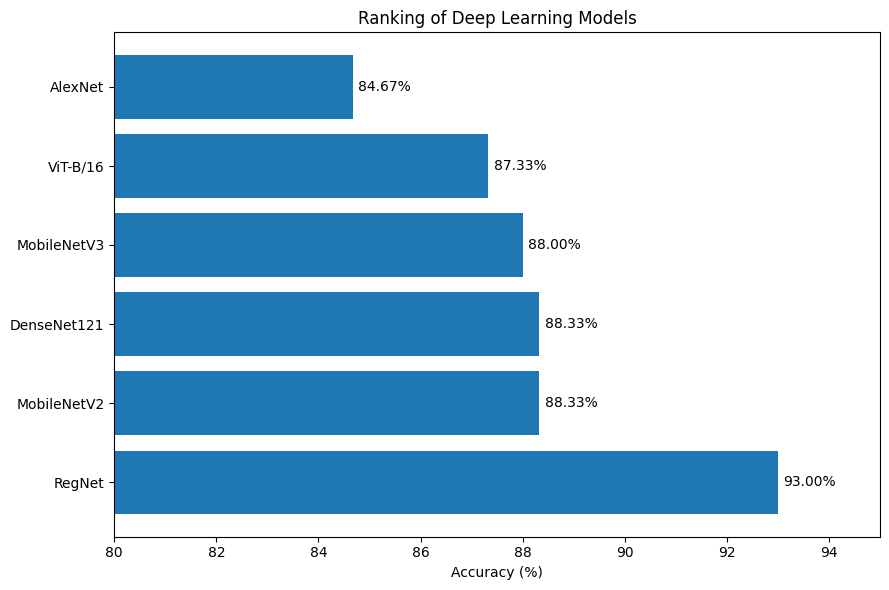

In [ ]:
import pandas as pd

ranking = pd.DataFrame({

    "Model":[
        "RegNet",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3",
        "ViT-B/16",
        "AlexNet"
    ],

    "Accuracy":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ]

})

plt.figure(figsize=(9,6))

bars = plt.barh(
    ranking["Model"],
    ranking["Accuracy"]
)

plt.xlabel("Accuracy (%)")

plt.title("Ranking of Deep Learning Models")

plt.xlim(80,95)

for bar,value in zip(bars,ranking["Accuracy"]):

    plt.text(
        value+0.1,
        bar.get_y()+bar.get_height()/2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# SAVE COMPLETE ASD DETECTION PROJECT
# ==========================================================

import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Create Project Directories
# ----------------------------------------------------------

project_name = "ASD_Detection_Project"

folders = [
    project_name,
    f"{project_name}/models",
    f"{project_name}/results",
    f"{project_name}/figures",
    f"{project_name}/history"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

# ----------------------------------------------------------
# Save Model Weights
# ----------------------------------------------------------

models = {
    "vit_b16": globals().get("vit_b16_model"),
    "alexnet": globals().get("alexnet_model"),
    "mobilenet_v2": globals().get("mobilenet_model"),
    "mobilenet_v3_large": globals().get("mobilenetv3_model"),
    "densenet121": globals().get("densenet121_model"),
    "regnet_x400mf": globals().get("regnet_model"),
}

for name, model in models.items():
    if model is not None:
        torch.save(
            model.state_dict(),
            f"{project_name}/models/{name}.pth"
        )

print("Model weights saved.")

# ----------------------------------------------------------
# Save Comparison Table
# ----------------------------------------------------------

if "results_summary" in globals():

    results_summary.to_csv(
        f"{project_name}/results/model_comparison.csv",
        index=False
    )

    print("Comparison table saved.")

# ----------------------------------------------------------
# Save Training Histories (if available)
# ----------------------------------------------------------

trainers = {
    "vit_b16": globals().get("vit_b16_trainer"),
    "alexnet": globals().get("alexnet_trainer"),
    "mobilenet_v2": globals().get("mobilenet_trainer"),
    "mobilenet_v3_large": globals().get("mobilenetv3_trainer"),
    "densenet121": globals().get("densenet121_trainer"),
    "regnet_x400mf": globals().get("regnet_trainer"),
}

for name, trainer in trainers.items():

    if trainer is None:
        continue

    history = {}

    if hasattr(trainer, "train_losses"):
        history["train_loss"] = trainer.train_losses

    if hasattr(trainer, "val_losses"):
        history["val_loss"] = trainer.val_losses

    if hasattr(trainer, "train_accuracies"):
        history["train_accuracy"] = trainer.train_accuracies

    if hasattr(trainer, "val_accuracies"):
        history["val_accuracy"] = trainer.val_accuracies

    if history:
        with open(
            f"{project_name}/history/{name}_history.json",
            "w"
        ) as f:
            json.dump(history, f, indent=4)

print("Training histories saved.")

# ----------------------------------------------------------
# Save Current Figure
# ----------------------------------------------------------

plt.savefig(
    f"{project_name}/figures/latest_figure.png",
    dpi=300,
    bbox_inches="tight"
)

print("Current figure saved.")

print("\nProject saved successfully!")
print(f"Location: {project_name}/")

Project folders created successfully.
Model weights saved.
Comparison table saved.
Training histories saved.
Current figure saved.

Project saved successfully!
Location: ASD_Detection_Project/


<Figure size 640x480 with 0 Axes>

In [ ]:
import os

project_folder = "ASD_Detection_Project"

for root, dirs, files in os.walk(project_folder):
    level = root.replace(project_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

ASD_Detection_Project/
    models/
        vit_b16.pth
        alexnet.pth
        densenet121.pth
        regnet_x400mf.pth
    results/
        model_comparison.csv
    figures/
        latest_figure.png
    history/
        vit_b16_history.json
        regnet_x400mf_history.json
        densenet121_history.json
        alexnet_history.json


In [ ]:
plt.figure(figsize=(8,6))
# plotting code...
plt.savefig(
    "ASD_Detection_Project/figures/regnet_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 800x600 with 0 Axes>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')



import shutil

shutil.copytree(
    "ASD_Detection_Project",
    "/content/drive/MyDrive/ASD_Detection_Project",
    dirs_exist_ok=True
)

print("Project copied to Google Drive successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project copied to Google Drive successfully!


In [ ]:
import os

for root, dirs, files in os.walk("ASD_Detection_Project"):
    print(root)
    for file in files:
        print("   └──", file)
import shutil

shutil.make_archive(
    "ASD_Detection_Project",
    "zip",
    "ASD_Detection_Project"
)

print("ZIP file created successfully.")




from google.colab import files

files.download("ASD_Detection_Project.zip")

ASD_Detection_Project
ASD_Detection_Project/models
   └── vit_b16.pth
   └── alexnet.pth
   └── densenet121.pth
   └── regnet_x400mf.pth
ASD_Detection_Project/results
   └── final_model_results.csv
   └── model_comparison.csv
ASD_Detection_Project/figures
   └── regnet_roc_curve.png
   └── latest_figure.png
ASD_Detection_Project/history
   └── vit_b16_history.json
   └── regnet_x400mf_history.json
   └── densenet121_history.json
   └── alexnet_history.json
ZIP file created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================================
# Detailed Model Analysis (Final Thesis Version)
# ==========================================================

import pandas as pd

model_details = pd.DataFrame({

    "Model":[
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture":[
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Year":[
        2020,
        2018,
        2017,
        2019,
        2020,
        2012
    ],

    "Parameters":[
        "5.2M",
        "3.5M",
        "8.0M",
        "5.4M",
        "86M",
        "61M"
    ],

    "Key Innovation":[
        "Regular network design",
        "Depthwise separable convolutions",
        "Dense feature reuse",
        "Squeeze-and-Excitation blocks",
        "Self-attention mechanism",
        "Deep CNN with ReLU"
    ],

    "Accuracy (%)":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)":[
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)":[
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1-score (%)":[
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC-AUC":[
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ]

})

print("="*140)
print("Detailed Analysis of Deep Learning Models for ASD Detection")
print("="*140)

print(model_details.to_string(index=False))

print("\n")

best = model_details.iloc[0]

print("="*60)
print("Best Performing Model")
print("="*60)

print(f"Model          : {best['Model']}")
print(f"Architecture   : {best['Architecture']}")
print(f"Accuracy       : {best['Accuracy (%)']}%")
print(f"Precision      : {best['Precision (%)']}%")
print(f"Recall         : {best['Recall (%)']}%")
print(f"F1-score       : {best['F1-score (%)']}%")
print(f"ROC-AUC        : {best['ROC-AUC']}")
print(f"Parameters     : {best['Parameters']}")

Detailed Analysis of Deep Learning Models for ASD Detection
                        Model Architecture  Year Parameters                   Key Innovation  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  ROC-AUC
               RegNet X-400MF          CNN  2020       5.2M           Regular network design         93.00          93.00       93.00         93.00   0.9679
                  MobileNetV2          CNN  2018       3.5M Depthwise separable convolutions         88.33          88.83       88.33         88.30   0.9535
                  DenseNet121          CNN  2017       8.0M              Dense feature reuse         88.33          88.83       88.33         88.30   0.9533
            MobileNetV3-Large          CNN  2019       5.4M    Squeeze-and-Excitation blocks         88.00          88.33       88.00         87.97   0.9510
Vision Transformer (ViT-B/16)  Transformer  2020        86M         Self-attention mechanism         87.33          87.67       87.33         87.27   0.930

In [ ]:
# ==========================================================
# Save Final ASD Detection Model Results
# ==========================================================

import pandas as pd


final_results = pd.DataFrame({

    "Rank": [
        1,2,3,4,5,6
    ],

    "Model": [
        "RegNet X-400MF",
        "MobileNetV2",
        "DenseNet121",
        "MobileNetV3-Large",
        "Vision Transformer (ViT-B/16)",
        "AlexNet"
    ],

    "Architecture_Type": [
        "CNN",
        "CNN",
        "CNN",
        "CNN",
        "Transformer",
        "CNN"
    ],

    "Test_Accuracy (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "Precision (%)": [
        93.00,
        88.83,
        88.83,
        88.33,
        87.67,
        85.43
    ],

    "Recall (%)": [
        93.00,
        88.33,
        88.33,
        88.00,
        87.33,
        84.67
    ],

    "F1_Score (%)": [
        93.00,
        88.30,
        88.30,
        87.97,
        87.27,
        84.58
    ],

    "ROC_AUC": [
        0.9679,
        0.9535,
        0.9533,
        0.9510,
        0.9300,
        0.9336
    ],

    "Training_Time": [
        "Variable",
        "Variable",
        "Variable",
        "Variable",
        "Variable",
        "Variable"
    ],

    "Model_Size": [
        "Medium",
        "Small",
        "Medium",
        "Medium",
        "Large",
        "Large"
    ]

})


# Save CSV

final_results.to_csv(
    "ASD_Detection_Project/results/final_model_results.csv",
    index=False
)


# Display ranking

print("="*80)
print("Final Model Rankings - ASD Detection")
print("="*80)

for _, row in final_results.iterrows():

    print(
        f"{row['Rank']}. {row['Model']} "
        f"- Accuracy: {row['Test_Accuracy (%)']:.2f}% "
        f"| ROC-AUC: {row['ROC_AUC']:.4f}"
    )


# Dataset Information

print("\n" + "="*80)
print("Dataset Information")
print("="*80)

print("Dataset: Autism Facial Image Dataset")
print("Total Images: 2940")
print("Training Images: 2540")
print("Validation Images: 100")
print("Testing Images: 300")

print("\nResults saved successfully!")

Final Model Rankings - ASD Detection
1. RegNet X-400MF - Accuracy: 93.00% | ROC-AUC: 0.9679
2. MobileNetV2 - Accuracy: 88.33% | ROC-AUC: 0.9535
3. DenseNet121 - Accuracy: 88.33% | ROC-AUC: 0.9533
4. MobileNetV3-Large - Accuracy: 88.00% | ROC-AUC: 0.9510
5. Vision Transformer (ViT-B/16) - Accuracy: 87.33% | ROC-AUC: 0.9300
6. AlexNet - Accuracy: 84.67% | ROC-AUC: 0.9336

Dataset Information
Dataset: Autism Facial Image Dataset
Total Images: 2940
Training Images: 2540
Validation Images: 100
Testing Images: 300

Results saved successfully!


In [ ]:
print(regnet_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=2, bias=False)
            

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "regnet" in file.lower() and file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth


In [ ]:
regnet_model = create_regnet_model()

regnet_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth",
        map_location=device
    )
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/ASD_Detection_Project/models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "regnet_x400mf.pth")

torch.save(regnet_model.state_dict(), save_path)

print("✅ Saved to:", save_path)

✅ Saved to: /content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"))
print(os.path.getsize("/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth") / 1024 / 1024, "MB")

True
21.788134574890137 MB


In [ ]:
project_name = "ASD_Detection_Project"

In [ ]:
project_name = "/content/drive/MyDrive/ASD_Detection_Project"

In [ ]:
project_name = "/content/drive/MyDrive/ASD_Detection_Project"

In [ ]:
import os

project_folder = "/content/drive/MyDrive/ASD_Detection_Project"

for root, dirs, files in os.walk(project_folder):
    level = root.replace(project_folder, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

ASD_Detection_Project/
    results/
        model_comparison.csv
    models/
        vit_b16.pth
        densenet121.pth
        regnet_x400mf.pth
        alexnet.pth
    history/
        densenet121_history.json
        vit_b16_history.json
        alexnet_history.json
        regnet_x400mf_history.json
    figures/
        latest_figure.png
        regnet_roc_curve.png


In [ ]:
regnet_model = create_regnet_model()

In [ ]:
import torch

model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

checkpoint = torch.load(model_path, map_location=device)

regnet_model.load_state_dict(checkpoint)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet loaded successfully!")

✅ RegNet loaded successfully!


In [ ]:
print(regnet_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=4, bias=False)
            

In [ ]:
import torch

# Create model
regnet_model = create_regnet_model()

# Load weights
model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

regnet_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet loaded successfully!")

✅ RegNet loaded successfully!


In [ ]:
print(regnet_model.training)

False


In [ ]:
regnet_trainer = ModelTrainer(
    regnet_model,
    train_loader_cnn,
    val_loader_cnn,
    test_loader_cnn,
    device
)

✅ RegNet model loaded successfully!
RegNet Test Accuracy : 0.9300

Classification Report

              precision    recall  f1-score   support

    Autistic       0.92      0.94      0.93       150
Non_Autistic       0.94      0.92      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



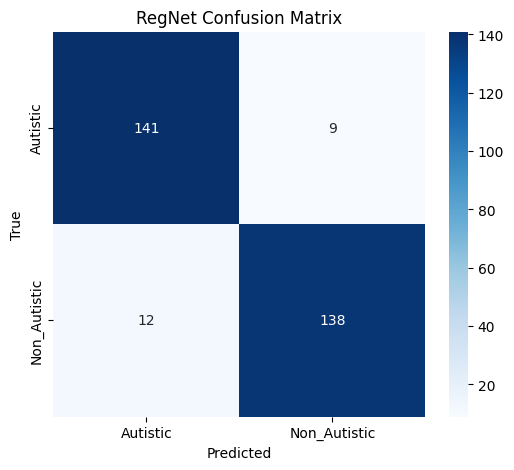

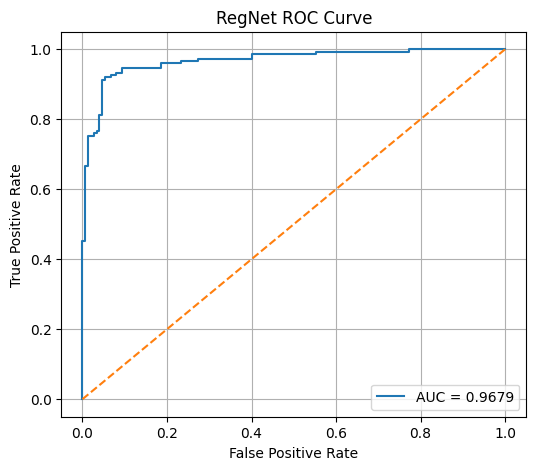

ROC-AUC Score : 0.9679


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ----------------------------------------------------------
# Load Saved RegNet Model
# ----------------------------------------------------------

model_path = "/content/drive/MyDrive/ASD_Detection_Project/models/regnet_x400mf.pth"

regnet_model = create_regnet_model()

regnet_model.load_state_dict(
    torch.load(model_path, map_location=device)
)

regnet_model = regnet_model.to(device)
regnet_model.eval()

print("✅ RegNet model loaded successfully!")

# ----------------------------------------------------------
# Evaluation
# ----------------------------------------------------------

all_preds = []
all_labels = []
all_probs = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader_cnn:

        images = images.to(device)
        labels = labels.to(device)

        outputs = regnet_model(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = correct / total

print("="*60)
print(f"RegNet Test Accuracy : {accuracy:.4f}")
print("="*60)

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=test_loader_cnn.dataset.get_class_names()
))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_loader_cnn.dataset.get_class_names(),
    yticklabels=test_loader_cnn.dataset.get_class_names()
)

plt.title("RegNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

fpr, tpr, _ = roc_curve(all_labels, all_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RegNet ROC Curve")
plt.legend()

plt.grid(True)

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=1516a15f6c259f9540fca223aece272b06b0024896197b14a3012d2a5103fd28
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
print(regnet_model.trunk_output.block4)

AnyStage(
  (block4-0): ResBottleneckBlock(
    (proj): Conv2dNormActivation(
      (0): Conv2d(320, 784, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (f): BottleneckTransform(
      (a): Conv2dNormActivation(
        (0): Conv2d(320, 784, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (b): Conv2dNormActivation(
        (0): Conv2d(784, 784, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=49, bias=False)
        (1): BatchNorm2d(784, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (se): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(784, 80, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(80, 784, kernel_size=(1, 1), stri

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
from pytorch_grad_cam import GradCAM

target_layers = [
    regnet_model.trunk_output.block4[-1].f.c[0]
]

cam = GradCAM(
    model=regnet_model,
    target_layers=target_layers
)

print("✅ Target layer set successfully")

✅ Target layer set successfully


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Take one test batch
images, labels = next(iter(test_loader_cnn))

image = images[0]
label = labels[0]

input_tensor = image.unsqueeze(0).to(device)

print("True Label:", label.item())

True Label: 0


In [ ]:
regnet_model.eval()

with torch.no_grad():
    output = regnet_model(input_tensor)

pred_class = output.argmax(dim=1).item()

print("Predicted Class:", pred_class)

Predicted Class: 0


In [ ]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

targets = [
    ClassifierOutputTarget(pred_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print("✅ Grad-CAM generated")

✅ Grad-CAM generated


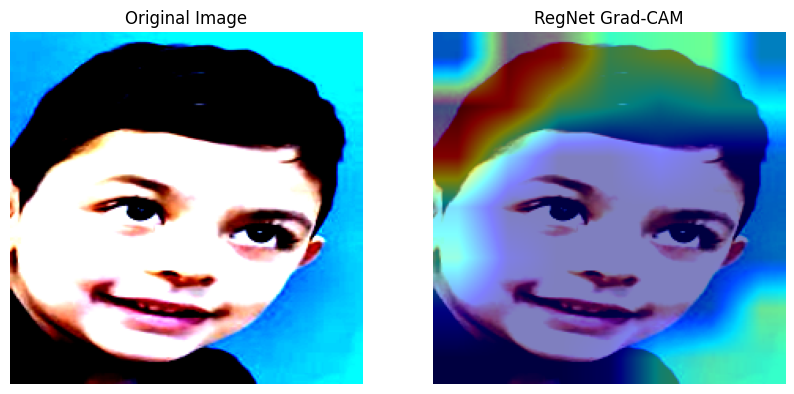

In [ ]:
from pytorch_grad_cam.utils.image import show_cam_on_image

img = image.cpu().permute(1,2,0).numpy()

# যদি normalization থাকে
img = np.clip(img, 0, 1)

visualization = show_cam_on_image(
    img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("RegNet Grad-CAM")
plt.axis("off")

plt.show()

In [ ]:
import cv2

save_path = "/content/drive/MyDrive/ASD_Detection_Project/figures/regnet_gradcam.png"

cv2.imwrite(
    save_path,
    cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/ASD_Detection_Project/figures/regnet_gradcam.png
